In [1]:
# ═══════════════════════════════════════════════════════
# DREAM NARRATOR — Notebook 01: Explore EEG Data
# ═══════════════════════════════════════════════════════
# PURPOSE: Interactively explore the raw EEG sleep data.
# This notebook teaches you what's inside the EDF files
# and visualizes brain waves before any processing.

import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

import numpy as np
import matplotlib.pyplot as plt
import mne

from configs.config_loader import config
from pipeline.data_loader import load_sleep_recording

print("Imports successful!")
print(f"MNE version: {mne.__version__}")

Imports successful!
MNE version: 1.11.0


In [2]:
# ── Load the EEG recording ──
# This loads the raw EDF file we downloaded from PhysioNet
# The same file a sleep researcher would work with in a lab

data_dir       = config['data']['raw_dir']
psg_path       = os.path.join(data_dir, config['data']['psg_file'])
hypnogram_path = os.path.join(data_dir, config['data']['hypnogram_file'])

raw, annotations = load_sleep_recording(psg_path, hypnogram_path)

# Basic info
print(f"Recording duration : {raw.times[-1]/3600:.2f} hours")
print(f"Sampling rate      : {raw.info['sfreq']} Hz")
print(f"Number of channels : {len(raw.ch_names)}")
print(f"Channel names      : {raw.ch_names}")
print(f"Total annotations  : {len(annotations)}")

Loading EEG recording from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf
Extracting EDF parameters from C:\Users\USER/mne_data/physionet-sleep-data\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(psg_path, preload=True)
C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:28: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(psg_path, preload=True)


Loading sleep stage annotations from: C:\Users\USER/mne_data/physionet-sleep-data\SC4001EC-Hypnogram.edf
Recording duration : 22.08 hours
Sampling rate      : 100.0 Hz
Number of channels : 7
Channel names      : ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Total annotations  : 154


C:\Users\USER\OneDrive\Desktop\dream-narrator\pipeline\data_loader.py:36: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


In [3]:
# ── Explore sleep stage annotations ──
# The hypnogram tells us which sleep stage the person
# was in at every moment of the night.
# This is the ground truth labeled by human experts.

print("SLEEP STAGE ANNOTATIONS:")
print("-" * 50)

# Count each sleep stage
stage_counts = {}
for annotation in annotations:
    stage = annotation['description']
    duration = annotation['duration']
    if stage not in stage_counts:
        stage_counts[stage] = {'count': 0, 'total_minutes': 0}
    stage_counts[stage]['count'] += 1
    stage_counts[stage]['total_minutes'] += duration / 60

print(f"{'Stage':<30} {'Epochs':>8} {'Minutes':>10}")
print("-" * 50)
for stage, data in sorted(stage_counts.items()):
    print(f"{stage:<30} {data['count']:>8} {data['total_minutes']:>10.1f}")

print("-" * 50)
print(f"\nTotal recording: {raw.times[-1]/3600:.2f} hours")

SLEEP STAGE ANNOTATIONS:
--------------------------------------------------
Stage                            Epochs    Minutes
--------------------------------------------------
Sleep stage 1                        24       29.0
Sleep stage 2                        40      125.0
Sleep stage 3                        48       50.5
Sleep stage 4                        23       59.5
Sleep stage ?                         1      115.0
Sleep stage R                         6       62.5
Sleep stage W                        12      998.5
--------------------------------------------------

Total recording: 22.08 hours


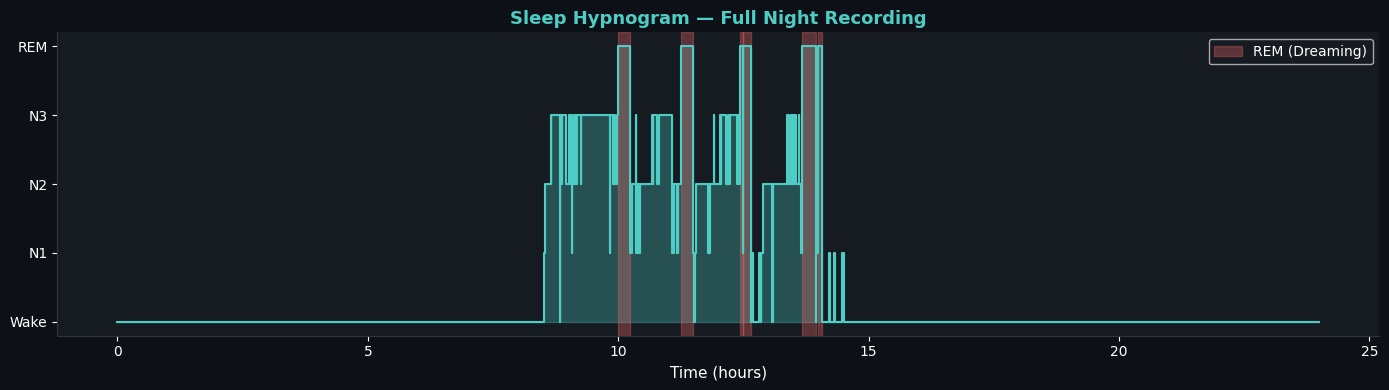

Red regions = REM sleep = dreaming periods


In [4]:
# ── Plot the hypnogram ──
# A hypnogram is the standard visualization in sleep research.
# It shows how a person cycled through sleep stages across the night.
# Every dip to REM is a potential dream period.

# Map stage names to numbers for plotting
stage_map = {
    'Sleep stage W' : 0,   # Wake
    'Sleep stage 1' : 1,   # Light sleep
    'Sleep stage 2' : 2,   # True sleep
    'Sleep stage 3' : 3,   # Deep sleep
    'Sleep stage 4' : 3,   # Deep sleep (same as 3)
    'Sleep stage R' : 4,   # REM ← dreams here
    'Movement time' : 0,   # Movement
}

# Build time and stage arrays
times  = []
stages = []

for annotation in annotations:
    stage    = annotation['description']
    onset    = annotation['onset'] / 3600  # convert to hours
    duration = annotation['duration'] / 3600
    stage_num = stage_map.get(stage, 0)
    times.append(onset)
    times.append(onset + duration)
    stages.append(stage_num)
    stages.append(stage_num)

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.plot(times, stages, color='#4ECDC4', linewidth=1.5)
ax.fill_between(times, stages, alpha=0.3, color='#4ECDC4')

# Mark REM periods in special color
for annotation in annotations:
    if 'R' in annotation['description']:
        onset    = annotation['onset'] / 3600
        duration = annotation['duration'] / 3600
        ax.axvspan(onset, onset + duration,
                  alpha=0.3, color='#FF6B6B',
                  label='REM (Dreaming)')

ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['Wake', 'N1', 'N2', 'N3', 'REM'],
                   color='white')
ax.set_xlabel('Time (hours)', color='white', fontsize=11)
ax.set_title('Sleep Hypnogram — Full Night Recording',
            color='#4ECDC4', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#30363D')
ax.spines['left'].set_color('#30363D')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
         facecolor='#161B22', labelcolor='white')

plt.tight_layout()
plt.show()

print("Red regions = REM sleep = dreaming periods")

Removing powerline noise at 50.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 47.50 Hz)
- Filter length: 661 samples (6.610 s)

Applying bandpass filter: 0.5 - 45.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transitio

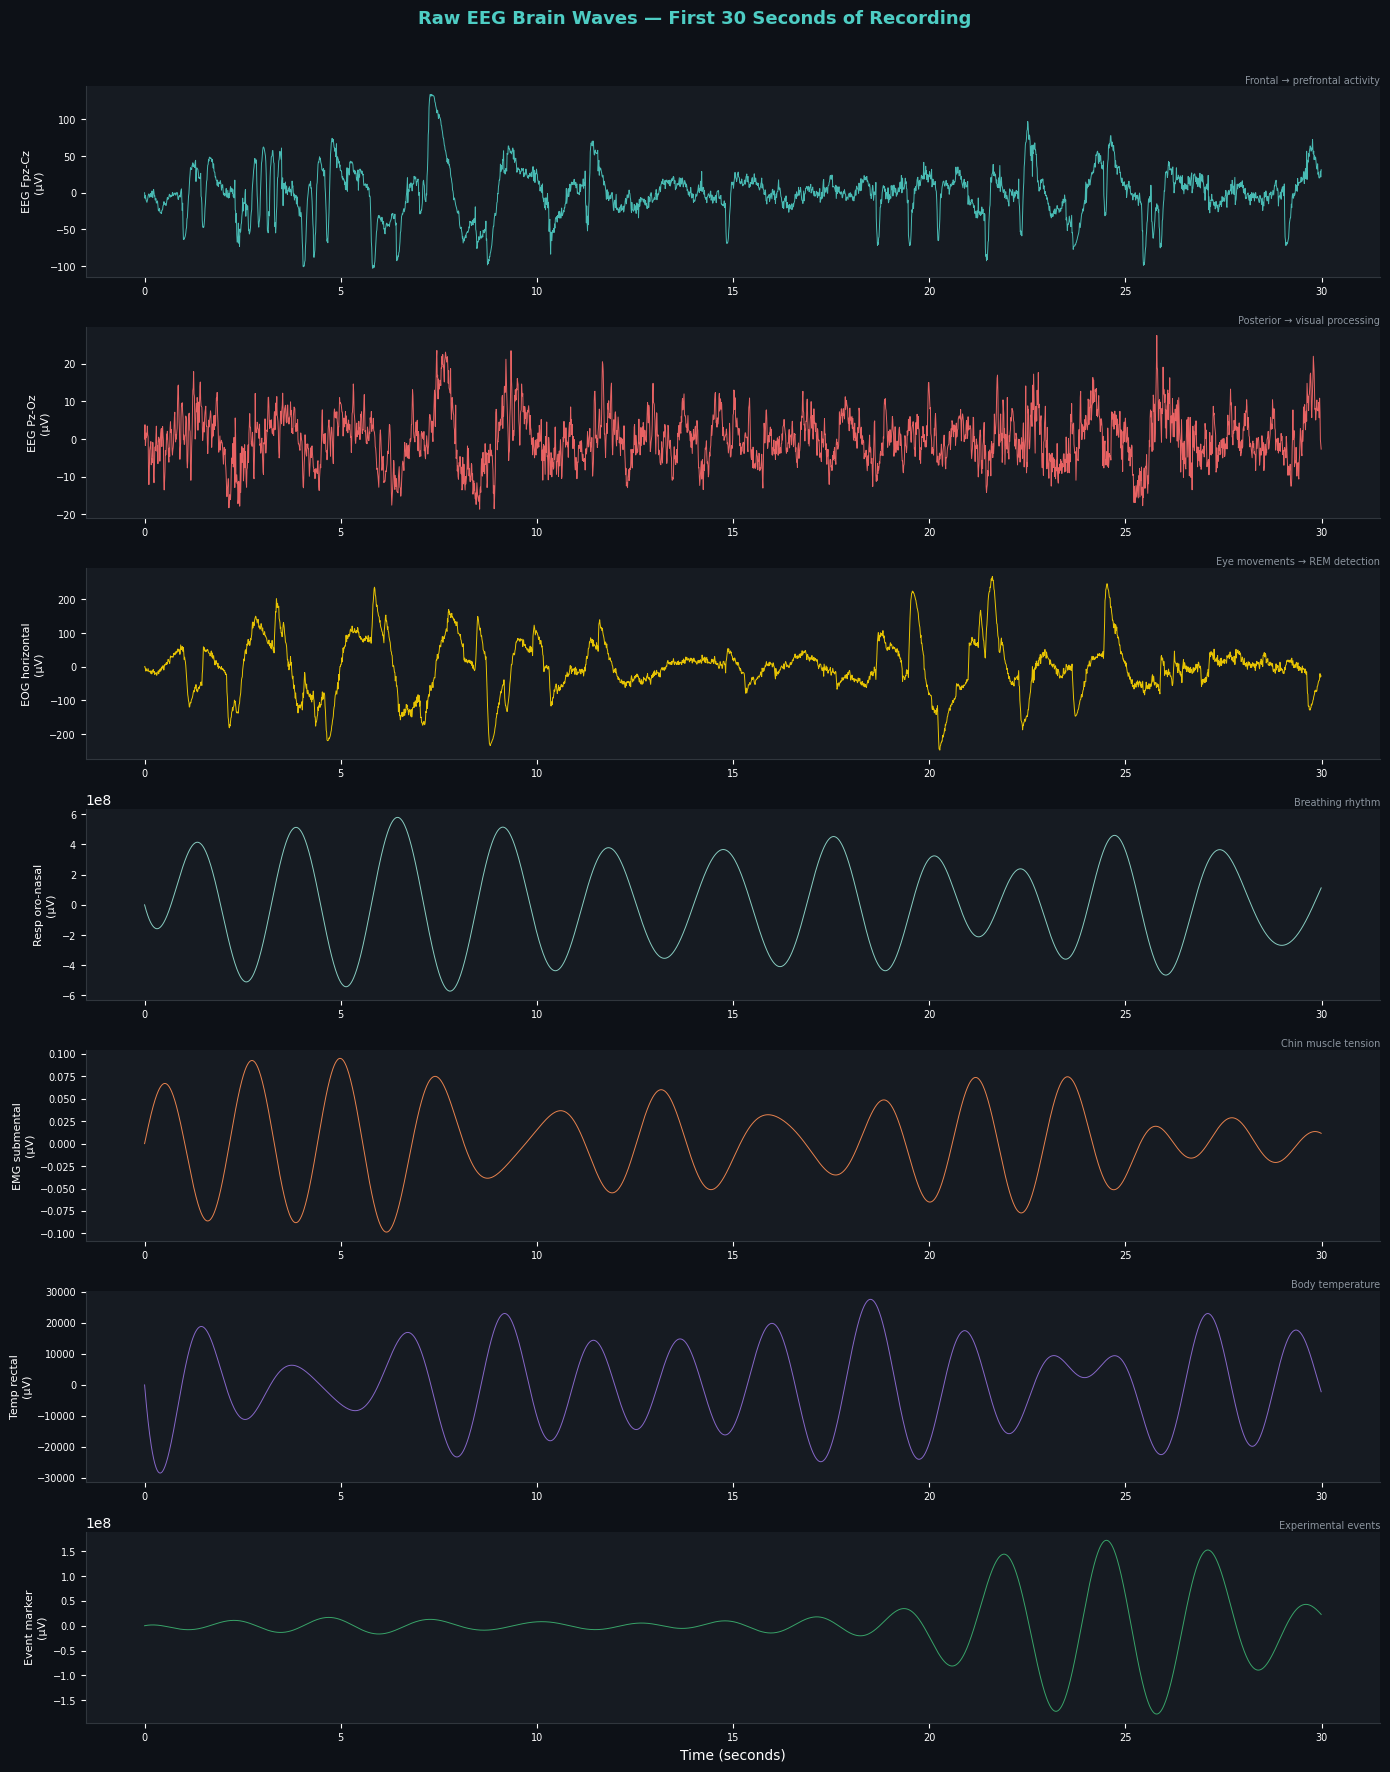

In [5]:
# ── Plot raw EEG brain waves ──
# Let's look at the actual voltage measurements
# from different brain regions during sleep.
# Each channel tells a different story.

from pipeline.preprocessor import bandpass_filter, remove_powerline_noise

# Clean the signal first
raw_clean = remove_powerline_noise(raw)
raw_clean = bandpass_filter(raw_clean)

# Get data
sfreq    = raw_clean.info['sfreq']
data     = raw_clean.get_data()
n_samples = int(sfreq * 30)  # first 30 seconds
times     = raw_clean.times[:n_samples]

# Plot each channel
colors = ['#4ECDC4', '#FF6B6B', '#FFD700',
          '#95E1D3', '#FF8E53', '#9370DB', '#3CB371']

fig, axes = plt.subplots(
    len(raw_clean.ch_names), 1,
    figsize=(14, 2.5 * len(raw_clean.ch_names))
)
fig.patch.set_facecolor('#0D1117')

if len(raw_clean.ch_names) == 1:
    axes = [axes]

for i, (ax, ch_name) in enumerate(
    zip(axes, raw_clean.ch_names)
):
    color        = colors[i % len(colors)]
    channel_data = data[i, :n_samples] * 1e6

    ax.plot(times, channel_data,
           color=color, linewidth=0.7, alpha=0.9)
    ax.set_facecolor('#161B22')
    ax.set_ylabel(f'{ch_name}\n(μV)',
                 color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    ax.spines['bottom'].set_color('#30363D')
    ax.spines['left'].set_color('#30363D')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add channel description
    descriptions = {
        'EEG Fpz-Cz' : 'Frontal → prefrontal activity',
        'EEG Pz-Oz'  : 'Posterior → visual processing',
        'EOG horizontal': 'Eye movements → REM detection',
        'Resp oro-nasal': 'Breathing rhythm',
        'EMG submental' : 'Chin muscle tension',
        'Temp rectal'   : 'Body temperature',
        'Event marker'  : 'Experimental events',
    }
    desc = descriptions.get(ch_name, '')
    ax.set_title(desc, color='#8B949E',
                fontsize=7, loc='right', pad=2)

    if i == len(raw_clean.ch_names) - 1:
        ax.set_xlabel('Time (seconds)',
                     color='white', fontsize=10)

plt.suptitle(
    'Raw EEG Brain Waves — First 30 Seconds of Recording',
    color='#4ECDC4', fontsize=13,
    fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

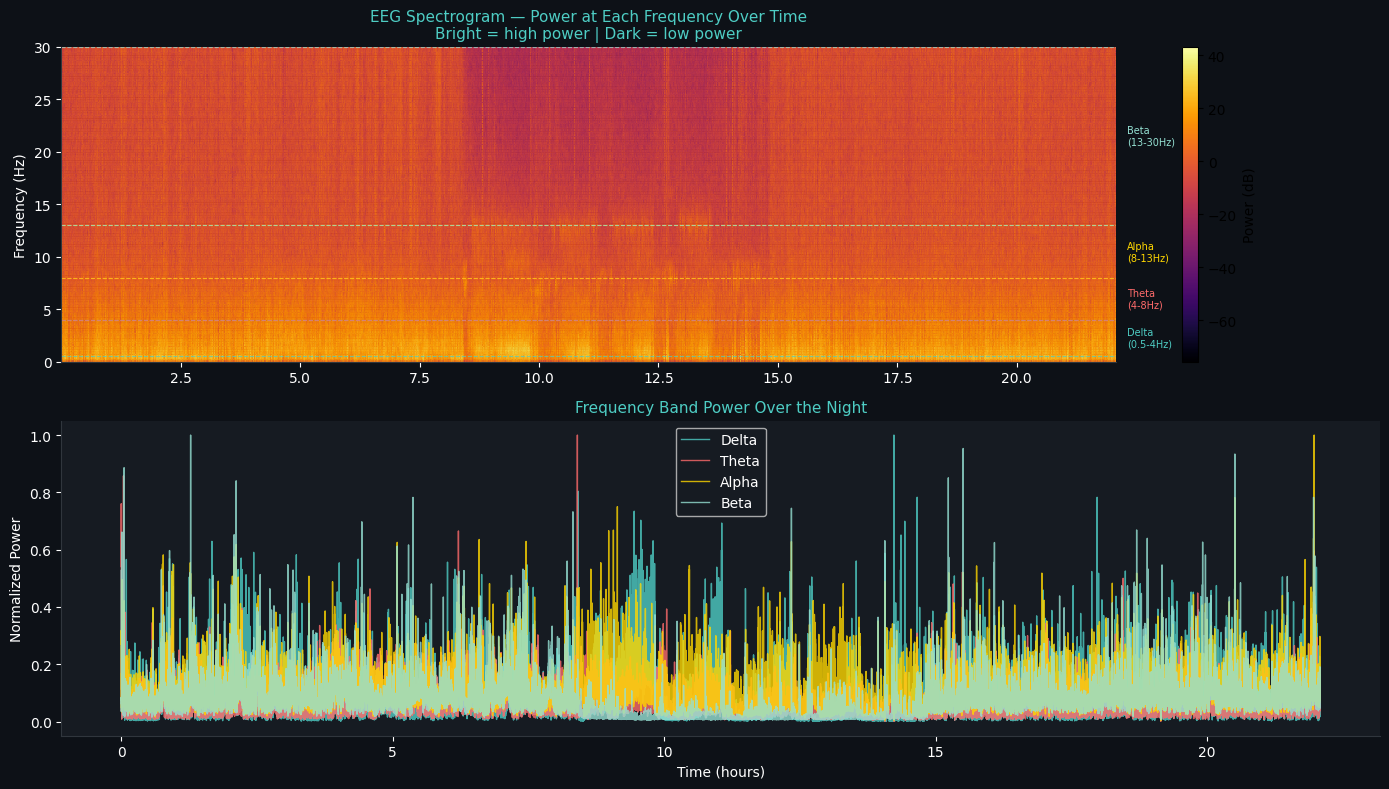

Notice how Delta power dominates deep sleep periods
and Theta power rises during REM (dreaming) periods!


In [6]:
# ── Visualize frequency band powers ──
# This is the most important visualization in EEG analysis.
# Instead of looking at raw waves, we look at HOW MUCH POWER
# exists at each frequency band across the recording.
#
# NEUROSCIENCE:
# Each band tells us what the brain is doing:
# Delta (0.5-4 Hz)  → deep sleep, slow wave activity
# Theta (4-8 Hz)    → dreaming, memory replay ← our target
# Alpha (8-13 Hz)   → relaxed wakefulness
# Beta  (13-30 Hz)  → active thinking, anxiety

from scipy import signal as scipy_signal

# Use first EEG channel only (Fpz-Cz — frontal)
eeg_channel = 0
eeg_data    = data[eeg_channel, :] * 1e6  # full recording in μV
sfreq_val   = int(sfreq)

# Compute spectrogram
# A spectrogram shows frequency content over TIME
# x-axis = time, y-axis = frequency, color = power
freqs, times_spec, Sxx = scipy_signal.spectrogram(
    eeg_data,
    fs=sfreq_val,
    nperseg=sfreq_val * 4,
    noverlap=sfreq_val * 2
)

# Convert time to hours
times_hours = times_spec / 3600

# Filter to relevant frequencies (0-30 Hz)
freq_mask = freqs <= 30
freqs_plot = freqs[freq_mask]
Sxx_plot   = Sxx[freq_mask, :]

# Plot spectrogram
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.patch.set_facecolor('#0D1117')

# ── Top: Spectrogram ──
ax1 = axes[0]
ax1.set_facecolor('#161B22')

im = ax1.pcolormesh(
    times_hours, freqs_plot,
    10 * np.log10(Sxx_plot + 1e-10),
    cmap='inferno', shading='gouraud'
)
plt.colorbar(im, ax=ax1, label='Power (dB)')

# Mark frequency bands
band_colors = {
    'Delta\n(0.5-4Hz)' : ('#4ECDC4', 0.5, 4),
    'Theta\n(4-8Hz)'   : ('#FF6B6B', 4, 8),
    'Alpha\n(8-13Hz)'  : ('#FFD700', 8, 13),
    'Beta\n(13-30Hz)'  : ('#95E1D3', 13, 30),
}

for label, (color, low, high) in band_colors.items():
    ax1.axhline(y=low,  color=color, linewidth=0.8,
               linestyle='--', alpha=0.7)
    ax1.axhline(y=high, color=color, linewidth=0.8,
               linestyle='--', alpha=0.7)
    ax1.text(times_hours[-1] * 1.01,
            (low + high) / 2,
            label, color=color, fontsize=7,
            va='center')

ax1.set_ylabel('Frequency (Hz)', color='white')
ax1.set_title(
    'EEG Spectrogram — Power at Each Frequency Over Time\n'
    'Bright = high power | Dark = low power',
    color='#4ECDC4', fontsize=11
)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Bottom: Band power over time ──
ax2 = axes[1]
ax2.set_facecolor('#161B22')

bands = {
    'Delta' : (0.5, 4,  '#4ECDC4'),
    'Theta' : (4,   8,  '#FF6B6B'),
    'Alpha' : (8,   13, '#FFD700'),
    'Beta'  : (13,  30, '#95E1D3'),
}

for band_name, (low, high, color) in bands.items():
    mask       = (freqs_plot >= low) & (freqs_plot <= high)
    band_power = np.mean(Sxx_plot[mask, :], axis=0)
    # Normalize for comparison
    band_power = band_power / (band_power.max() + 1e-10)
    ax2.plot(times_hours, band_power,
            label=band_name, color=color,
            linewidth=1, alpha=0.8)

ax2.set_xlabel('Time (hours)', color='white')
ax2.set_ylabel('Normalized Power', color='white')
ax2.set_title(
    'Frequency Band Power Over the Night',
    color='#4ECDC4', fontsize=11
)
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('#30363D')
ax2.spines['left'].set_color('#30363D')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(facecolor='#161B22', labelcolor='white')

plt.tight_layout()
plt.show()

print("Notice how Delta power dominates deep sleep periods")
print("and Theta power rises during REM (dreaming) periods!")

Extracting features from all epochs...
Feature matrix shape: (20, 63)
(20 epochs × 63 features)


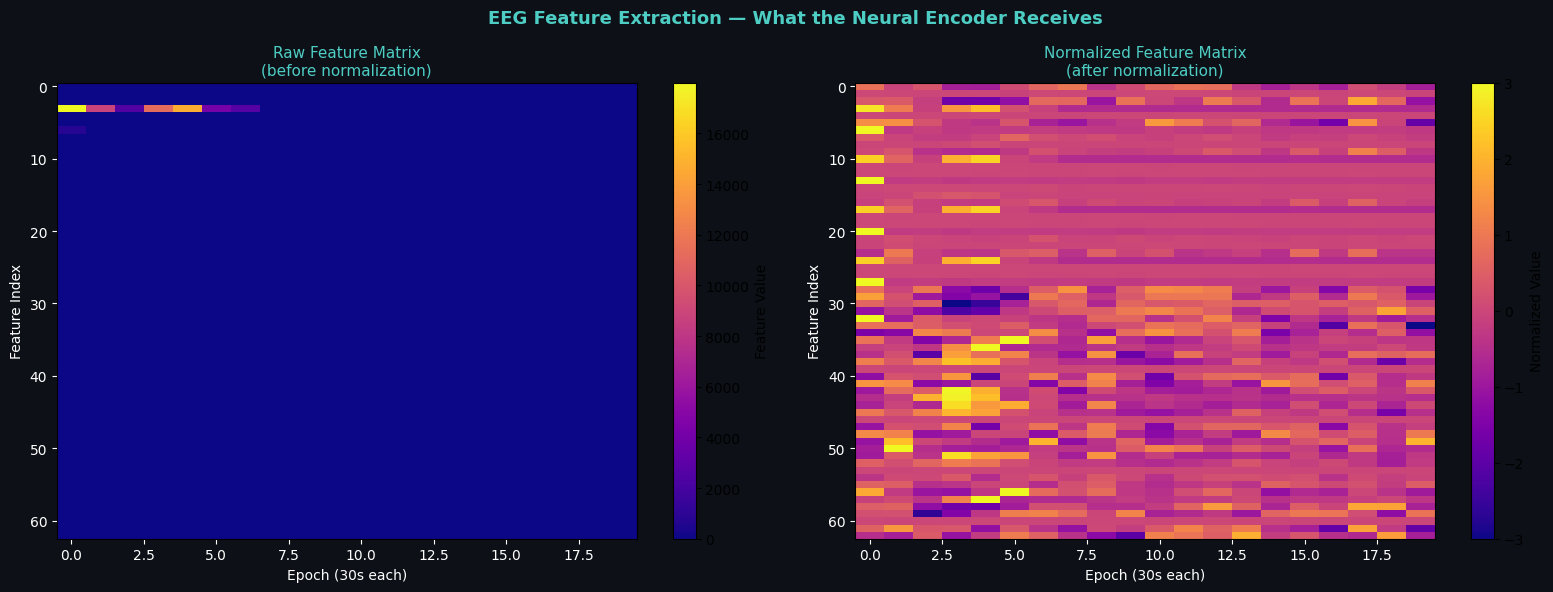


Left plot: raw values — huge scale differences between features
Right plot: normalized — all features on same scale
This is WHY normalization was critical for training!


In [7]:
# ── Visualize extracted features ──
# Let's see what our feature extractor actually produces
# for each 30-second epoch across the recording.
# This shows the INPUT to our neural encoder.

from pipeline.feature_extractor import extract_features_from_epoch

print("Extracting features from all epochs...")

epoch_duration = int(sfreq * 30)
n_epochs       = min(20, data.shape[1] // epoch_duration)

all_features   = []
epoch_indices  = []

for i in range(n_epochs):
    start      = i * epoch_duration
    end        = start + epoch_duration
    epoch_data = data[:, start:end]
    features, names = extract_features_from_epoch(epoch_data, sfreq)
    all_features.append(features)
    epoch_indices.append(i)

features_array = np.array(all_features)
print(f"Feature matrix shape: {features_array.shape}")
print(f"({n_epochs} epochs × {features_array.shape[1]} features)")

# ── Plot feature heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Left: raw feature heatmap
ax1 = axes[0]
ax1.set_facecolor('#161B22')
im1 = ax1.imshow(
    features_array.T,
    aspect='auto',
    cmap='plasma',
    interpolation='nearest'
)
plt.colorbar(im1, ax=ax1, label='Feature Value')
ax1.set_xlabel('Epoch (30s each)', color='white')
ax1.set_ylabel('Feature Index', color='white')
ax1.set_title('Raw Feature Matrix\n(before normalization)',
             color='#4ECDC4', fontsize=11)
ax1.tick_params(colors='white')

# Right: normalized feature heatmap
ax2 = axes[1]
ax2.set_facecolor('#161B22')

mean = features_array.mean(axis=0)
std  = features_array.std(axis=0) + 1e-10
features_normalized = (features_array - mean) / std

im2 = ax2.imshow(
    features_normalized.T,
    aspect='auto',
    cmap='plasma',
    interpolation='nearest',
    vmin=-3, vmax=3
)
plt.colorbar(im2, ax=ax2, label='Normalized Value')
ax2.set_xlabel('Epoch (30s each)', color='white')
ax2.set_ylabel('Feature Index', color='white')
ax2.set_title('Normalized Feature Matrix\n(after normalization)',
             color='#4ECDC4', fontsize=11)
ax2.tick_params(colors='white')

plt.suptitle(
    'EEG Feature Extraction — What the Neural Encoder Receives',
    color='#4ECDC4', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nLeft plot: raw values — huge scale differences between features")
print("Right plot: normalized — all features on same scale")
print("This is WHY normalization was critical for training!")

Embeddings shape: (20, 16)
(20 epochs × 16 dimensions)

PCA explained variance: 63.7%
(how much information is preserved in 2D)


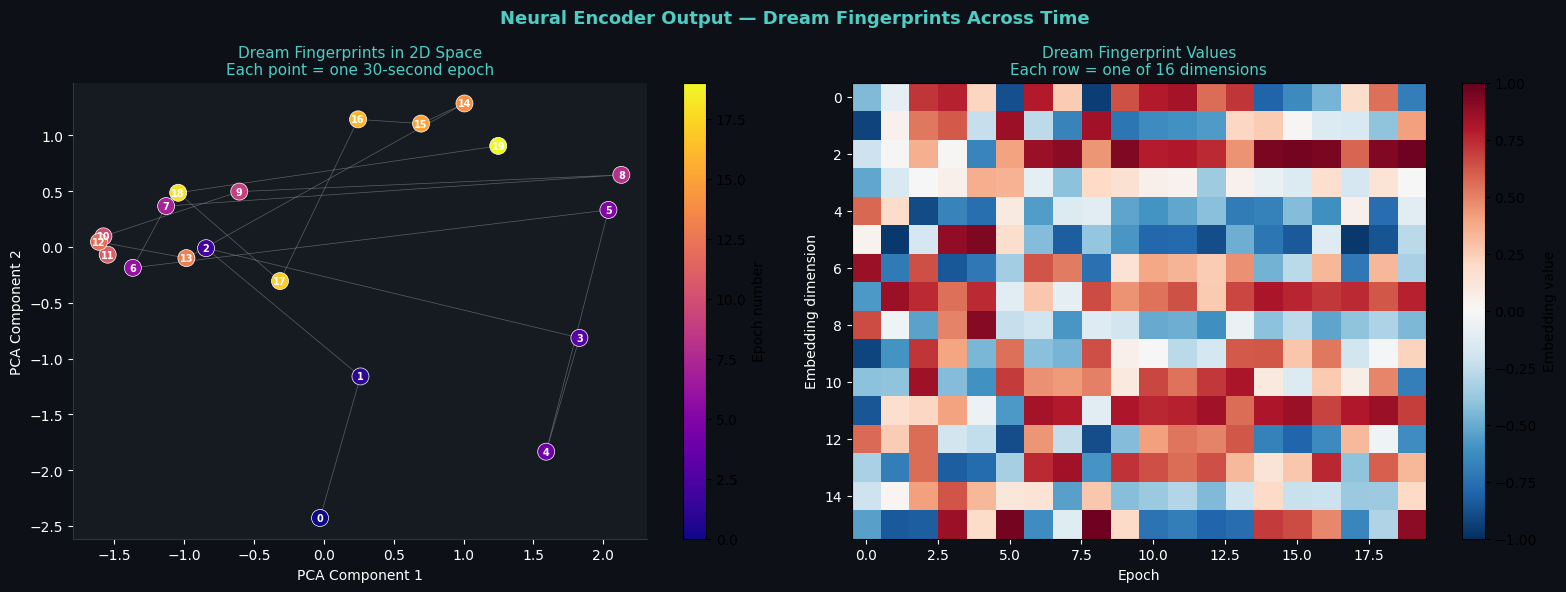


Left plot: dream fingerprints projected to 2D
Points that are CLOSE = similar brain states
Points that are FAR = different brain states

Right plot: raw 16-dimensional fingerprint values
Notice how patterns change across epochs!


In [11]:
# ── Visualize dream fingerprints ──
# Let's see what the neural encoder produces —
# the 16-number dream fingerprints for each epoch.
# This shows us the LATENT SPACE of our dreams.
#
# WHAT TO LOOK FOR:
# - Do similar epochs cluster together?
# - Can we see patterns across the recording?
# - How different are early vs late epochs?

import torch
from pipeline.neural_encoder import DreamEncoder
from sklearn.decomposition import PCA

# ── Load encoder ──
input_dim = features_array.shape[1]
model     = DreamEncoder(
    input_dim=input_dim,
    embedding_dim=config['encoder']['embedding_dim']
)
model.load_state_dict(
    torch.load(os.path.join('..', config['encoder']['model_path']))
)
model.eval()

# ── Generate embeddings ──
embeddings = []
with torch.no_grad():
    for features in features_normalized:
        x            = torch.FloatTensor(features).unsqueeze(0)
        embedding, _ = model(x)
        embeddings.append(embedding.numpy().flatten())

embeddings_array = np.array(embeddings)
print(f"Embeddings shape: {embeddings_array.shape}")
print(f"({n_epochs} epochs × {embeddings_array.shape[1]} dimensions)")

# ── Reduce to 2D for visualization using PCA ──
# PCA = Principal Component Analysis
# It finds the 2 directions of maximum variance
# so we can plot 16D embeddings on a 2D screen
# WHY PCA: We can't visualize 16 dimensions directly.
# PCA is the standard dimensionality reduction for visualization.
pca         = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_array)

print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("(how much information is preserved in 2D)")

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Left: 2D PCA scatter plot
ax1 = axes[0]
ax1.set_facecolor('#161B22')

scatter = ax1.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=epoch_indices,
    cmap='plasma',
    s=150,
    edgecolors='white',
    linewidths=0.5,
    zorder=2
)
plt.colorbar(scatter, ax=ax1, label='Epoch number')

# Connect points in sequence to show trajectory
ax1.plot(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    color='white', linewidth=0.5,
    alpha=0.3, zorder=1
)

# Label each point
for i, (x, y) in enumerate(embeddings_2d):
    ax1.annotate(
        str(i), (x, y),
        fontsize=7, color='white',
        ha='center', va='center',
        fontweight='bold'
    )

ax1.set_xlabel('PCA Component 1', color='white')
ax1.set_ylabel('PCA Component 2', color='white')
ax1.set_title(
    'Dream Fingerprints in 2D Space\n'
    'Each point = one 30-second epoch',
    color='#4ECDC4', fontsize=11
)
ax1.tick_params(colors='white')
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: embedding heatmap across epochs
ax2 = axes[1]
ax2.set_facecolor('#161B22')

im = ax2.imshow(
    embeddings_array.T,
    aspect='auto',
    cmap='RdBu_r',
    interpolation='nearest',
    vmin=-1, vmax=1
)
plt.colorbar(im, ax=ax2, label='Embedding value')
ax2.set_xlabel('Epoch', color='white')
ax2.set_ylabel('Embedding dimension', color='white')
ax2.set_title(
    'Dream Fingerprint Values\n'
    'Each row = one of 16 dimensions',
    color='#4ECDC4', fontsize=11
)
ax2.tick_params(colors='white')

plt.suptitle(
    'Neural Encoder Output — Dream Fingerprints Across Time',
    color='#4ECDC4', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nLeft plot: dream fingerprints projected to 2D")
print("Points that are CLOSE = similar brain states")
print("Points that are FAR = different brain states")
print("\nRight plot: raw 16-dimensional fingerprint values")
print("Notice how patterns change across epochs!")

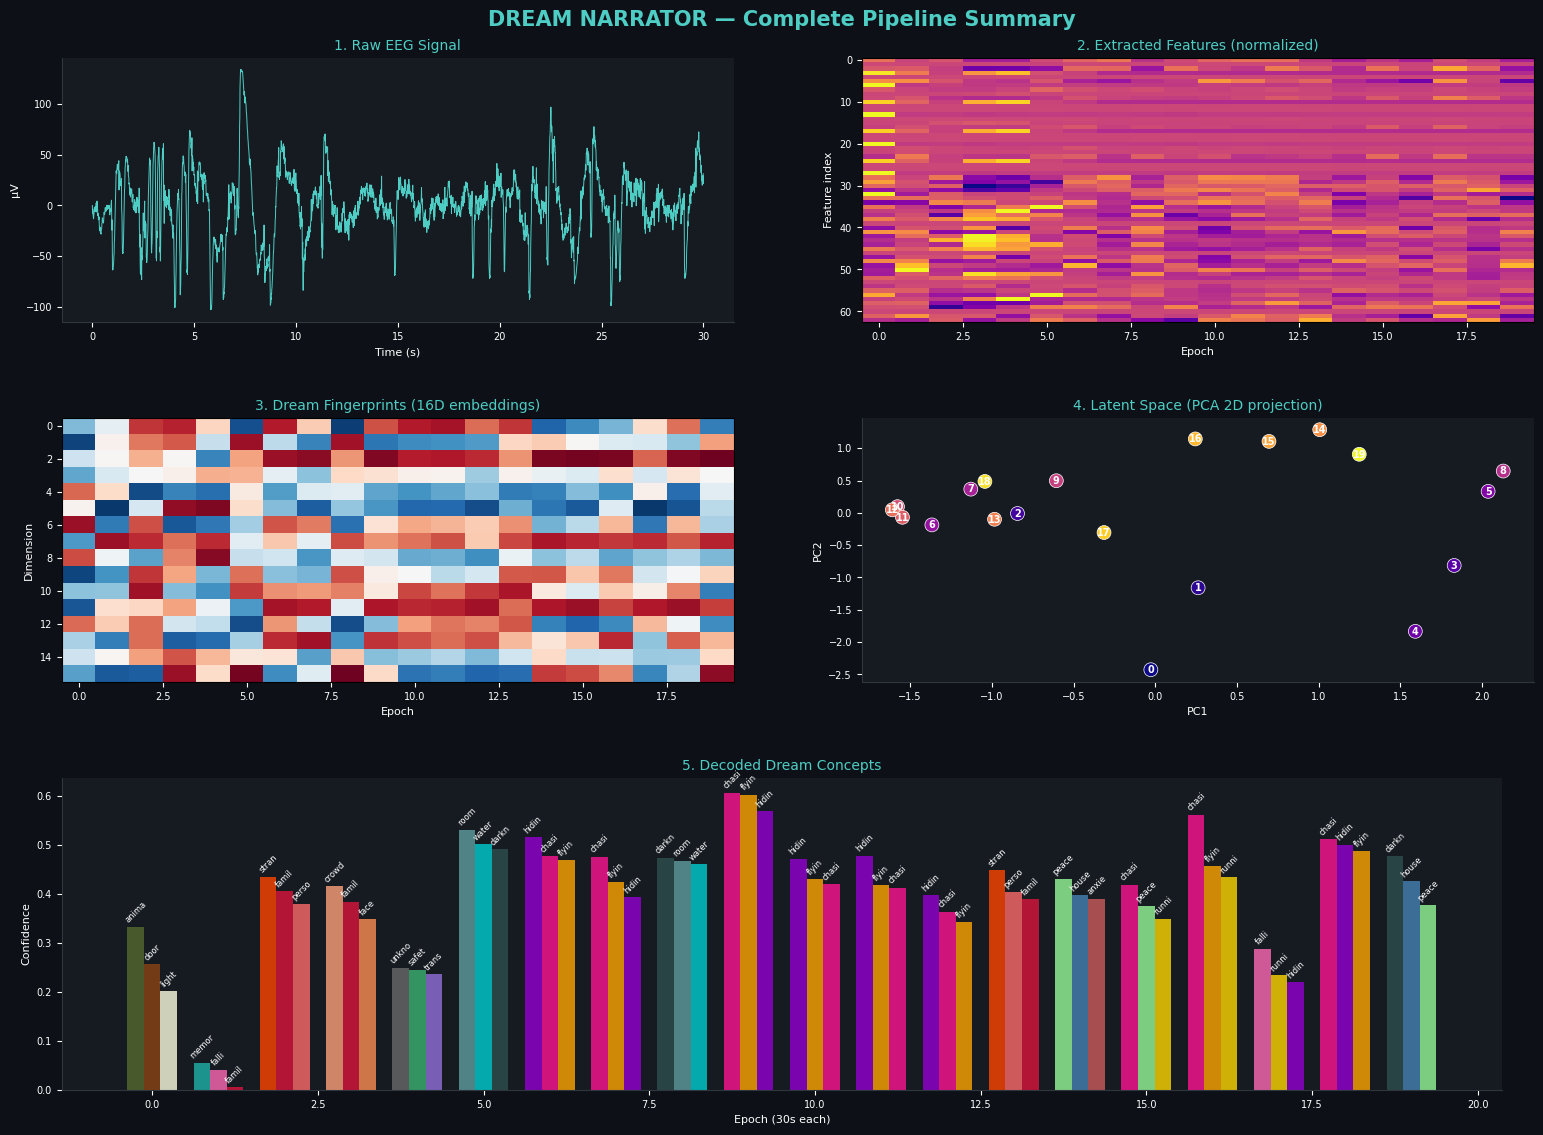


Pipeline summary saved to data/processed/pipeline_summary.png

DOMINANT DREAM THEMES:
  chasing        : 9x
  flying         : 8x
  hiding         : 8x
  family         : 4x
  darkness       : 3x


In [15]:
# ── Full pipeline summary visualization ──
# This is the money shot — showing the entire pipeline
# from raw EEG to decoded concepts in one figure.
# Perfect for presentations and the README.

from pipeline.semantic_decoder import SemanticDecoder

# ── Decode concepts ──
decoder          = SemanticDecoder(
    embedding_dim=config['encoder']['embedding_dim']
)
decoded_sequence = decoder.decode_sequence(
    [np.array(e) for e in embeddings_array],
    top_n=3
)
dominant_themes  = decoder.summarize_sequence(decoded_sequence)

# ── Build summary figure ──
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0D1117')

# Title
fig.text(
    0.5, 0.98,
    'DREAM NARRATOR — Complete Pipeline Summary',
    color='#4ECDC4', fontsize=15,
    fontweight='bold', ha='center', va='top'
)

# ── Panel 1: Raw EEG (top left) ──
ax1 = fig.add_axes([0.05, 0.72, 0.42, 0.22])
ax1.set_facecolor('#161B22')
n_plot = int(sfreq * 30)
ax1.plot(
    raw_clean.times[:n_plot],
    data[0, :n_plot] * 1e6,
    color='#4ECDC4', linewidth=0.7
)
ax1.set_title('1. Raw EEG Signal',
             color='#4ECDC4', fontsize=10)
ax1.set_xlabel('Time (s)', color='white', fontsize=8)
ax1.set_ylabel('μV', color='white', fontsize=8)
ax1.tick_params(colors='white', labelsize=7)
ax1.spines['bottom'].set_color('#30363D')
ax1.spines['left'].set_color('#30363D')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: Feature heatmap (top right) ──
ax2 = fig.add_axes([0.55, 0.72, 0.42, 0.22])
ax2.set_facecolor('#161B22')
ax2.imshow(
    features_normalized.T,
    aspect='auto', cmap='plasma',
    interpolation='nearest',
    vmin=-3, vmax=3
)
ax2.set_title('2. Extracted Features (normalized)',
             color='#4ECDC4', fontsize=10)
ax2.set_xlabel('Epoch', color='white', fontsize=8)
ax2.set_ylabel('Feature index', color='white', fontsize=8)
ax2.tick_params(colors='white', labelsize=7)

# ── Panel 3: Dream fingerprints (middle left) ──
ax3 = fig.add_axes([0.05, 0.42, 0.42, 0.22])
ax3.set_facecolor('#161B22')
ax3.imshow(
    embeddings_array.T,
    aspect='auto', cmap='RdBu_r',
    interpolation='nearest',
    vmin=-1, vmax=1
)
ax3.set_title('3. Dream Fingerprints (16D embeddings)',
             color='#4ECDC4', fontsize=10)
ax3.set_xlabel('Epoch', color='white', fontsize=8)
ax3.set_ylabel('Dimension', color='white', fontsize=8)
ax3.tick_params(colors='white', labelsize=7)

# ── Panel 4: PCA of embeddings (middle right) ──
ax4 = fig.add_axes([0.55, 0.42, 0.42, 0.22])
ax4.set_facecolor('#161B22')
scatter = ax4.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=epoch_indices, cmap='plasma',
    s=100, edgecolors='white',
    linewidths=0.5
)
for i, (x, y) in enumerate(embeddings_2d):
    ax4.annotate(str(i), (x, y),
                fontsize=7, color='white',
                ha='center', va='center',
                fontweight='bold')
ax4.set_title('4. Latent Space (PCA 2D projection)',
             color='#4ECDC4', fontsize=10)
ax4.set_xlabel('PC1', color='white', fontsize=8)
ax4.set_ylabel('PC2', color='white', fontsize=8)
ax4.tick_params(colors='white', labelsize=7)
ax4.spines['bottom'].set_color('#30363D')
ax4.spines['left'].set_color('#30363D')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Panel 5: Decoded concepts (bottom) ──
ax5 = fig.add_axes([0.05, 0.08, 0.90, 0.26])
ax5.set_facecolor('#161B22')

from viz.dream_timeline import CONCEPT_COLORS

for epoch_data in decoded_sequence:
    epoch    = epoch_data['epoch']
    concepts = epoch_data['concepts']
    for i, (concept, score) in enumerate(concepts):
        color = CONCEPT_COLORS.get(concept, '#4ECDC4')
        x     = epoch + (i - 1) * 0.25
        ax5.bar(x, score, width=0.25,
               color=color, alpha=0.8)
        ax5.text(x, score + 0.005, concept[:5],
                ha='center', va='bottom',
                fontsize=6, color='white', rotation=45)

ax5.set_title('5. Decoded Dream Concepts',
             color='#4ECDC4', fontsize=10)
ax5.set_xlabel('Epoch (30s each)',
              color='white', fontsize=8)
ax5.set_ylabel('Confidence',
              color='white', fontsize=8)
ax5.tick_params(colors='white', labelsize=7)
ax5.spines['bottom'].set_color('#30363D')
ax5.spines['left'].set_color('#30363D')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)


plt.savefig(
    os.path.join('..', 'data/processed/pipeline_summary.png'),
    dpi=150, bbox_inches='tight',
    facecolor='#0D1117'
)
plt.show()

print("\nPipeline summary saved to data/processed/pipeline_summary.png")
print("\nDOMINANT DREAM THEMES:")
for concept, data_c in dominant_themes[:5]:
    print(f"  {concept:15}: {data_c['count']}x")